# R-KV Token Dropping — Route B, buffered / chunked, on the CPU
---

Long prompts create large KV caches. They eat GPU memory, limit how many requests
fit in a batch, and a smaller batch means lower decode throughput. *Token
dropping* shrinks each request's KV cache — by half in this notebook — so more
requests fit and decoding runs faster.

This notebook uses the LMCache SDK to pull a request's KV cache out after
prefill, compress it, and put it back before decode. The compression algorithm
is **R-KV**: it ranks past tokens by **attention importance**, like SnapKV, and
subtracts a second term, **redundancy** — how similar a token's key is to the
*other* keys:

$$\text{score}(j) \;=\; \lambda \cdot \underbrace{\text{importance}(j)}_{\text{attended to?}} \;-\; (1-\lambda) \cdot \underbrace{\text{redundancy}(j)}_{\text{says something new?}}$$

Keeping tokens that are both attended-to **and** non-redundant works especially
well on the repetitive output of reasoning models. The catch is that the
redundancy term compares **all pairs of keys**: $O(n^2 d)$ per layer, against
$O(w n d)$ for SnapKV's importance term. At $n = 16128$ with window $w = 64$
that is ~250x more arithmetic per layer, and a literal implementation also
materializes an $n \times n$ matrix per layer.

## This notebook

It takes the other branch, **route B**: keys are compared only inside a chunk,
which makes the similarity matrix block-diagonal and the redundancy term
$O(n c d)$. This is the approach the R-KV serving ports take. It is an
**approximation** — ~96% kept-token agreement with the exact route — and it is
the quickest CPU option, included so the trade-off is on the table.

It is one of four independent notebooks that keep the same 50% of the tokens and
therefore deliver the **same decode speed-up** — 1766–1785 tok/s, a 1.1% spread, even
though they compress with completely different code. What separates them is the **cost of
compressing**:

| | [one-shot](../rkv_token_dropping.ipynb) | [cpu_exact](./rkv_variant_cpu_exact.ipynb) | [gpu_exact](./rkv_variant_gpu_exact.ipynb) | [buffered_cpu](./rkv_variant_buffered_cpu.ipynb) |
|---|---|---|---|---|
| Formulation | route A, literal | route A, linear | route A, linear | route B, chunked |
| Exact? | yes (the reference) | yes, rel. err ~2e-6 | yes, rel. err ~5e-7 | **no**, ~96% agreement |
| Redundancy cost | $O(n^2 d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ |
| VRAM | ~9.8 GiB | none | **1.55 GiB** | none |
| Compress 30 requests | 41.6 s | 67.3 s | **37.5 s** | **29.9 s** |
| Decode throughput | 1766 tok/s | 1785 tok/s | 1774 tok/s | 1774 tok/s |
| Accuracy (baseline 10–11/30) | 16/30 | 15/30 | 16/30 | 14/30 |


Start with the [one-shot notebook](../rkv_token_dropping.ipynb): it is R-KV
written the way the paper describes it, and it is the reference the exact
variants here are checked against.

Numbers above were measured on 30 LongBench-v2 prompts (~16k tokens each) with
Qwen3-8B on one H200 and a 96-core Xeon. They are hardware- and
workload-dependent; treat them as reference measurements, not guarantees.

## Requirements

* A small ~10-line modification to vLLM exposes intermediate tensors to LMCache.
  See [README.md](../README.md).
* A GPU is required for serving. To see token dropping increase the decode batch
  size, tune the GPU memory utilization together with the number of requests.
* Data moves between the LMCache server and the SDK through shared memory; if it
  is unavailable the SDK falls back to pickle.
* Run this notebook from its own directory; it imports `../utils.py`.


## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 400 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
LMCACHE_TRANSFER_INTERMEDIATE_TENSORS=true \
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once

sys.path.append("..")  # utils.py lives next to the main notebook

from utils import (  # noqa: E402
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

[2026-08-12 00:15:29,130] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/sigma/github/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)


[2026-08-12 00:15:29,208] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.4.dev21 (g0c487832)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [2]:
model_name = "/data/models/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

# Streams prefilled per submission. LMCache's query ring buffer maps a forward
# step's query rows to ring slots positionally (qringbuffer.py
# build_q_step_state), assuming each request contributed exactly its store op's
# token count of rows. Continuous batching breaks that, so the captured queries
# are silently wrong or short. Measured query-row reproducibility across two
# identical runs: 100.0% at 1 stream, 99.7% at 4, 9.8% at 30. R-KV's importance
# term is entirely query-driven, so prefill is submitted one stream at a time.
prefill_group_size = 1

## Configuring the model and LMCache endpoint

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-08-12 00:15:29,649] LMCache INFO: Initialized LMCacheSDKContext with instance_id=4310895948349885523, model_name=/data/models/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:122:lmcache.sdk.context)


[2026-08-12 00:15:29,651] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:879:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-12 00:15:29,823] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-12 00:15:29,828] LMCache INFO: Engine KV Format: 7 NL x [NB, 2, NH, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)


[2026-08-12 00:15:29,830] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=268435456000) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)


...

[2026-08-12 00:15:48,446] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-12 00:15:48,447] LMCache INFO: Engine KV Format: 3 NL x [NB, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)


[2026-08-12 00:15:48,448] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=268435456000) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)


[2026-08-12 00:16:06,929] LMCache INFO: SHM pinned=True for shm_name=lmcache_l1_pool_lmcache_sdk (shm.py:118:lmcache.v1.multiprocess.transfer_context.shm)


[2026-08-12 00:16:06,930] LMCache INFO: Worker non-GPU transfer context registered (instance_id=2484444406789004949, mode=SHM) (worker_transfer.py:745:lmcache.v1.multiprocess.transfer_context.worker_transfer)


## Constructing Prompt

In [4]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Using the latest cached version of the dataset since raniayu/token-dropping-demo couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at /home/sigma/.cache/huggingface/datasets/raniayu___token-dropping-demo/default/0.0.0/0581768ecd24dea91b4af0dea6c30e526282e929 (last modified on Fri Jul 24 22:25:51 2026).


Loaded 30 prompts from the dataset.
Total prompts length: 423428 tokens.
Mean prompt length: 14114.27 tokens.
Max prompt length: 16807 tokens.
Min prompt length: 10159 tokens.


## Baseline (without token dropping)


In [5]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-12 00:16:10,515] LMCache INFO: prefill: 2.73 s in groups of 1 (420791162.py:24:__main__)


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       154.80
Total Output Tokens:                                                      153510
Decode Throughput (tokens/s):                                             991.64


## Clear LMCache


In [6]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

## With R-KV Token Dropping — Route B, buffered / chunked, on the CPU

In [7]:
# Standard
import os

# --- R-KV hyperparameters ----------------------------------------------------
# Scores are averaged over KV heads and summed over layers, so a request keeps
# ONE token subset. LMCache re-injects a single contiguous KV with a single
# kept-token list, so per-head eviction is not expressible here.
rkv_window_size = 16  # observation window: the last w queries vote on importance
rkv_drop_ratio = 0.5  # fraction of tokens to evict
rkv_kernel_size = 7  # max-pool width applied to the importance scores
rkv_mix_lambda = 0.25  # score = lambda * importance - (1 - lambda) * redundancy
rkv_sim_threshold = 0.5  # cosine above this counts as "similar"

# --- CPU thread budget (shared by both CPU implementations) ------------------
cpu_thread_oversubscription = 1.25  # total intra-op threads / usable cores
cpu_reserve_cores = 4  # left for vLLM, the LMCache server and the OS
cpu_device = torch.device("cpu")


def usable_cores():
    """Cores this process may actually run on -- affinity and cgroup, not nproc."""
    try:
        cores = len(os.sched_getaffinity(0))
    except AttributeError:
        cores = os.cpu_count() or 1
    try:
        with open("/sys/fs/cgroup/cpu.max") as fh:
            quota, period = fh.read().split()
        if quota != "max":
            cores = min(cores, max(1, int(int(quota) // int(period))))
    except (OSError, ValueError):
        pass
    return max(1, cores)


def plan_cpu_threads():
    """Set torch's intra-op threads so intra_op * workers ~= 1.25 * cores.

    `batch.modify` runs one worker thread per stream and torch defaults to one
    intra-op thread per core inside each of them, which on a 96-core box means
    30 x 96 = 2880 runnable threads. Measured over 30 requests: 27.6 s at 96
    intra-op threads, 19.8 s at 4, 33.5 s at 1.
    """
    cores = usable_cores()
    budget = max(1, round((cores - cpu_reserve_cores) * cpu_thread_oversubscription))
    workers = max(1, len(prompts))
    intra_op = max(1, min(budget // workers, budget))
    torch.set_num_threads(intra_op)
    logger.info(
        f"CPU thread plan: {cores} usable cores -> budget {budget}, "
        f"{workers} workers -> torch.set_num_threads({intra_op}) "
        f"(~{intra_op * workers} runnable threads)"
    )
    return intra_op


cpu_intraop_threads = plan_cpu_threads()


# --- Tensor plumbing ---------------------------------------------------------
def model_heads():
    """(num_q_heads, num_kv_heads, head_dim) for the served model."""
    q = config.num_attention_heads
    kv = getattr(config, "num_key_value_heads", q)
    return q, kv, getattr(config, "head_dim", config.hidden_size // q)


def to_heads(flat, rows, heads, head_dim, device=None):
    """[rows, heads * head_dim] -> [1, heads, rows, head_dim] in fp32."""
    t = (
        flat.to(dtype=torch.float32)
        if device is None
        else flat.to(device, torch.float32)
    )
    return t.reshape(rows, heads, head_dim).permute(1, 0, 2).unsqueeze(0)


def q_by_layer(q_tensor):
    """Normalise the SDK's query tensor to [num_layers, T, q_heads * head_dim]."""
    if q_tensor.ndim == 4 and q_tensor.shape[0] == 1:
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"unexpected q_tensor shape {tuple(q_tensor.shape)}")


def attention_logits(query, key, pooling="max"):
    """q @ k^T / sqrt(d), pooled from query heads down to KV heads (GQA).

    query: [1, q_heads, q_len, d]   key: [1, kv_heads, kv_len, d]
    """
    _, q_heads, q_len, d = query.shape
    kv_heads = key.shape[1]
    group = q_heads // kv_heads
    if group == 1:
        return torch.matmul(query, key.transpose(2, 3)) / math.sqrt(d)
    q = query.view(1, kv_heads, group, q_len, d)
    attn = torch.matmul(q, key.unsqueeze(2).transpose(3, 4)) / math.sqrt(d)
    return attn.mean(dim=2) if pooling == "mean" else attn.max(dim=2).values


def importance(k, q_win, past_len):
    """How much the observation window attends to each past token.

    Only the window queries are passed in, so this is O(w * n * d) rather than
    the O(n^2 * d) the reference spends before discarding all but the last w rows.
    """
    attn = attention_logits(q_win, k)[:, :, :, :past_len]
    scores = F.softmax(attn, dim=-1, dtype=torch.float32).mean(dim=-2)
    return F.max_pool1d(
        scores, kernel_size=rkv_kernel_size, padding=rkv_kernel_size // 2, stride=1
    )


def redundancy_reference(key_states, threshold=rkv_sim_threshold):
    """Literal R-KV redundancy: materialises the whole n x n matrix.

    Only used as the correctness oracle in the self-tests -- never on a real
    prompt, where it would allocate kv_heads * n^2 floats per layer.
    """
    _, _, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(k, k.transpose(-1, -2))
    eye = torch.eye(n, dtype=torch.bool, device=k.device).view(1, 1, n, n)
    sim.masked_fill_(eye, 0.0)

    # Per row, exempt the LARGEST column index that is above threshold (or
    # column 0 if none qualifies) -- R-KV's `similarity_retain` rule.
    mask = sim > threshold
    idx = torch.arange(n, device=k.device).view(1, 1, 1, n)
    retain = torch.where(mask, idx, torch.zeros_like(mask, dtype=torch.long))
    sim.scatter_(-1, retain.max(dim=-1)[0].unsqueeze(-1), 0)
    return sim.mean(dim=-2).softmax(dim=-1)


def prepare(tensors, token_source):
    """Common bookkeeping shared by every drop_tokens_fn."""
    kv = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]  # [2, L, T, D]
    q = q_by_layer(tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY])
    seq_len = min(kv.shape[2], q.shape[1], len(token_source))
    past_len = seq_len - rkv_window_size
    if past_len <= 0:
        raise ValueError(f"seq_len {seq_len} must exceed window {rkv_window_size}")
    keep_total = int(round(seq_len * (1 - rkv_drop_ratio)))
    keep_past = max(0, min(keep_total - rkv_window_size, past_len))
    q_win = q[:, past_len:seq_len, :]  # window only: ~2.4 MiB, not ~4.8 GiB
    return kv, q_win, seq_len, past_len, keep_past


def select(scores, past_len, seq_len, keep_past):
    """Top-scoring past tokens plus the whole observation window."""
    top = torch.topk(scores, k=keep_past).indices.sort().values
    tail = torch.arange(past_len, seq_len, device=scores.device)
    return torch.cat([top, tail]).to(torch.long).cpu()


def rerotate(kv_tensor, keep_idx, device):
    """Gather the kept tokens and move their RoPE to the new positions."""
    gathered = kv_tensor[:, :, keep_idx, :].clone().to(device)
    out = rerotate_k_cache(
        gathered,
        old_positions=keep_idx.to(device),
        new_positions=torch.arange(keep_idx.numel(), device=device),
        model_config=config,
    )
    return out.cpu()

[2026-08-12 00:18:45,528] LMCache INFO: CPU thread plan: 96 usable cores -> budget 115, 30 workers -> torch.set_num_threads(3) (~90 runnable threads) (3184414291.py:49:__main__)


### Route B, buffered / chunked, on the CPU

> **Trades exactness for CPU speed.** The only implementation here that does
> not reproduce R-KV: it judges redundancy locally, which makes it the quickest
> CPU option but changes ~4% of the kept tokens.
>
> | | |
> |---|---|
> | **Buys you** | Fastest CPU compression (2.25× quicker than [`cpu_exact`](./rkv_variant_cpu_exact.ipynb)), no VRAM, straightforward code |
> | **Costs you** | **Exactness** — redundancy is judged only within a chunk, so ~4% of the kept tokens differ and answer quality can move |
> | Exact? | No — ~96% kept-token agreement with route A |
> | VRAM | None |
> | Compress 30 requests | 29.9 s |
> | Decode throughput | 1774 tok/s |
> | Pick it when | Compression latency matters more than reproducing R-KV exactly |

The other three notebooks all compute route A: every token is judged against
the *whole* prompt. **Route B** is the other branch, the one the R-KV
serving ports take (`buffered_keep` in the SGLang port): cut the prompt into
chunks and compress within a chunk. It is an **approximation** — included here
so the trade-off is on the table when picking an option.

## The idea: a block-diagonal similarity matrix

Restricting the pairwise key comparison to tokens in the *same* chunk makes the
similarity matrix block-diagonal, so the redundancy term costs

$$\frac{n}{c} \text{ blocks} \times O(c^2 d) \;=\; O(n \cdot c \cdot d)$$

— linear in $n$ for a fixed chunk size $c$, and the transient tensor shrinks
from $\text{kv\_heads} \cdot n^2$ to $\text{kv\_heads} \cdot n \cdot c$.

Two deliberate departures from SGLang's `buffered_keep`:

* **Importance stays global.** It is already only $O(w n d)$, and keeping it
  global means every token is still ranked against the *true* final observation
  window. SGLang's sequential version scores against a mid-prefill window and
  therefore evicts tokens a later chunk would have attended to; this variant has
  **no premature eviction**. The locality of the redundancy term is the only
  approximation.
* **One global top-k**, not a per-chunk quota, so the budget can flow to the
  informative regions. Both cost the same — the score vector is global either
  way — so this is accuracy for free. Set `buffered_chunk_quota = True` for the
  literal "compress each chunk independently, then concatenate" reading.

Scale is preserved so the term stays comparable against
$\lambda \cdot \text{importance}$: each column is a mean over **its own chunk's
real rows** (the padded trailing chunk divides by its true length), followed by
a **single global softmax**.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Chunking itself.** | The whole point: $O(n^2 d) \to O(n c d)$. At $n = 16128$, $c = 512$ that is **13.9×** off the one-shot cost. |
| 2 | **One batched GEMM over all chunks**, `[1, kv_heads, n/c, c, c]`, instead of a Python loop over chunks. | Keeps oneDNN on a single large call rather than $n/c$ small ones. |
| 3 | **Thread budgeting** (see the shared cell above). | `batch.modify` gives 30-way outer parallelism while torch defaults to one intra-op thread per core *inside each worker* — 30 × 96 = 2880 runnable threads on a 96-core box. Measured over 30 requests: **27.6 s at 96 intra-op threads, 19.8 s at 4**, 33.5 s at 1. Worth ~1.4× on its own. |
| 4 | **fp32, not bf16.** | This Xeon has AMX-BF16, yet bf16 was *slower* (1.95 s vs 1.29 s at $c = 512$). Once chunked, the kernel is bound by the compare / flip / argmax / scatter — memory-bound ops AMX does not accelerate. |

## Choosing the chunk size

Measured on one request, $n = 16128$, $L = 36$, against the exact route-A result:

| chunk `c` | s/request | vs. one-shot | kept-token agreement |
|---|---|---|---|
| 2048 | 3.27 s | 5.5× | 98.19% |
| 1024 | 1.78 s | 10.1× | 97.31% |
| **512** | **1.29 s** | **13.9×** | **95.89%** |
| 256 | 1.01 s | 17.8× | 94.08% |

**Result: the fastest CPU option (29.9 s to compress 30 requests, 2.25× quicker
than the exact CPU version) at the cost of ~4% of the kept tokens.** Pick this
when compression latency matters more than reproducing R-KV exactly; pick [`cpu_exact`](./rkv_variant_cpu_exact.ipynb) or [`gpu_exact`](./rkv_variant_gpu_exact.ipynb) when
it does not.


In [8]:
# --- Knobs -------------------------------------------------------------------
buffered_chunk_size = 512  # smaller = faster, but a more local redundancy call
buffered_chunk_quota = False  # False = one global top-k; True = per-chunk quota


def _buffered_redundancy(key_states, chunk_size):
    """Block-diagonal redundancy: keys are only compared inside their chunk.

    Same reduction order as route A (mean down the columns, then softmax across
    them), but the row set for column j is limited to j's own chunk, which makes
    the cost O(n * c * d) instead of O(n^2 * d).

    key_states: [1, kv_heads, n, d] -> [1, kv_heads, n]
    """
    bsz, kv_heads, n, head_dim = key_states.shape
    c = max(1, min(chunk_size, n))
    n_chunks = (n + c - 1) // c
    pad = n_chunks * c - n

    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    if pad:
        # Padded rows are exactly zero: they add nothing to a real column's sum
        # and never clear the similarity threshold.
        k = F.pad(k, (0, 0, 0, pad))
    kb = k.reshape(bsz, kv_heads, n_chunks, c, head_dim)

    # One batched GEMM over every chunk, not a Python loop.
    sim = torch.matmul(kb, kb.transpose(-1, -2))  # [1, kv_heads, n_chunks, c, c]
    diag = torch.arange(c)
    sim[..., diag, diag] = 0.0  # a token is not redundant with itself

    # Route A's `similarity_retain`, searched within the chunk only.
    over = sim > rkv_sim_threshold
    has = over.any(dim=-1)
    last = (c - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
    retain = torch.where(has, last, torch.zeros_like(last))
    sim.scatter_(-1, retain.unsqueeze(-1), 0.0)

    col_sum = sim.sum(dim=-2)  # [1, kv_heads, n_chunks, c]
    del sim, over, has, last, retain

    # Mean over each chunk's REAL rows; the padded trailing chunk is shorter and
    # dividing it by c would understate its redundancy.
    rows = torch.full((n_chunks,), float(c))
    if pad:
        rows[-1] = float(c - pad)
    col_sum = col_sum / rows.view(1, 1, n_chunks, 1)

    col_sum = col_sum.reshape(bsz, kv_heads, n_chunks * c)[:, :, :n]
    return col_sum.softmax(dim=-1)  # one GLOBAL softmax keeps route A's scale


def _select_chunk_quota(scores, keep_past, chunk_size):
    """Per-chunk top-k: each chunk keeps its own proportional share.

    The literal "compress every chunk independently" reading, used when
    `buffered_chunk_quota` is True. Remainders go to the earlier chunks so the
    total is exactly `keep_past`.
    """
    past_len = scores.numel()
    n_chunks = (past_len + chunk_size - 1) // chunk_size
    base, extra = divmod(keep_past, n_chunks)

    picks = []
    for ci in range(n_chunks):
        lo, hi = ci * chunk_size, min((ci + 1) * chunk_size, past_len)
        quota = min(base + (1 if ci < extra else 0), hi - lo)
        if quota > 0:
            picks.append(torch.topk(scores[lo:hi], k=quota).indices + lo)
    return torch.cat(picks).sort().values


def drop_tokens_buffered(tensors, token_source):
    """Route B token dropping, entirely on the CPU."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()

    scores = torch.zeros(past_len, dtype=torch.float32)
    for layer in range(kv.shape[1]):
        k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim)
        qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim)
        imp = importance(k, qw, past_len)  # unchanged: still the true final window
        red = _buffered_redundancy(k, buffered_chunk_size)[:, :, :past_len]
        scores += (imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)).mean(1).squeeze(0)

    if buffered_chunk_quota:
        top = _select_chunk_quota(scores, keep_past, buffered_chunk_size)
        tail = torch.arange(past_len, seq_len)
        keep_idx = torch.cat([top, tail]).to(torch.long)
    else:
        keep_idx = select(scores, past_len, seq_len, keep_past)

    e_kv = rerotate(kv, keep_idx, cpu_device)
    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_buffered(n=2048, layers=4):
    """Report agreement with route A -- this one is an approximation.

    Unlike the exact implementations this cannot assert equality, so it checks
    the shapes and reports the overlap: a bug in the padding or the rescaling
    shows up as a collapse in agreement instead of passing silently.
    """
    torch.manual_seed(0)
    num_q, num_kv, head_dim = model_heads()
    past_len = n - rkv_window_size
    keep = int(round(n * (1 - rkv_drop_ratio))) - rkv_window_size
    ref, got = torch.zeros(past_len), torch.zeros(past_len)

    for _ in range(layers):
        k = torch.randn(1, num_kv, n, head_dim)
        qw = torch.randn(1, num_q, rkv_window_size, head_dim)
        imp = importance(k, qw, past_len)
        red_a = redundancy_reference(k)[:, :, :past_len]
        red_b = _buffered_redundancy(k, buffered_chunk_size)[:, :, :past_len]
        ref += (imp * rkv_mix_lambda - red_a * (1 - rkv_mix_lambda)).mean(1).squeeze(0)
        got += (imp * rkv_mix_lambda - red_b * (1 - rkv_mix_lambda)).mean(1).squeeze(0)

    assert got.shape == ref.shape and torch.isfinite(got).all()
    a = set(torch.topk(ref, keep).indices.tolist())
    b = set(torch.topk(got, keep).indices.tolist())
    overlap = len(a & b) / len(a)
    logger.info(
        f"Route B self-test (n={n}, chunk={buffered_chunk_size}): "
        f"kept-token agreement with route A = {overlap:.2%}"
    )
    assert overlap > 0.80, f"route B diverged too far from route A ({overlap:.2%})"


_selftest_buffered()

[2026-08-12 00:18:46,056] LMCache INFO: Route B self-test (n=2048, chunk=512): kept-token agreement with route A = 98.51% (549056236.py:124:__main__)


In [9]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_buffered)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
buffered_drop_data = results.to_dict()
buffered_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-12 00:19:01,315] LMCache INFO: prefill: 15.23 s in groups of 1 (2839406187.py:24:__main__)


[2026-08-12 00:19:19,131] LMCache INFO: compacted 4992/9984 tokens. (549056236.py:94:__main__)


[2026-08-12 00:19:19,471] LMCache INFO: compacted 5120/10240 tokens. (549056236.py:94:__main__)


[2026-08-12 00:19:21,023] LMCache INFO: compacted 5504/11008 tokens. (549056236.py:94:__main__)


[2026-08-12 00:19:21,094] LMCache INFO: compacted 5376/10752 tokens. (549056236.py:94:__main__)


...

[2026-08-12 00:19:31,449] LMCache INFO: compacted 8320/16640 tokens. (549056236.py:94:__main__)


[2026-08-12 00:19:31,497] LMCache INFO: compacted 7936/15872 tokens. (549056236.py:94:__main__)


[2026-08-12 00:19:31,683] LMCache INFO: 

 (2839406187.py:29:__main__)


======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        30.37


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        86.42
Total Output Tokens:                                                      153420
Decode Throughput (tokens/s):                                            1775.25


### Accuracy


In [10]:
before_correct, total, before_map = score_answers(answers, before_texts)
after_correct, total, after_map = score_answers(answers, buffered_texts)

logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"R-KV buffered: {after_correct}/{total} correct "
    f"({100 * after_correct / total:.1f}%)"
)

[2026-08-12 00:20:58,117] LMCache INFO: Baseline (no drop): 10/30 correct (33.3%) (3348946064.py:4:__main__)


[2026-08-12 00:20:58,118] LMCache INFO: R-KV buffered: 14/30 correct (46.7%) (3348946064.py:8:__main__)


## Result Plot


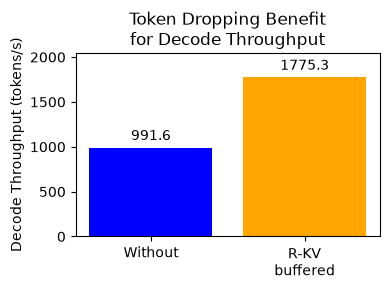

In [11]:
labels = ["Without", "R-KV\nbuffered"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    buffered_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Reading these numbers

All four notebooks were run back to back on one machine against the same vLLM
and LMCache servers, and each re-measures its own no-drop baseline. That gives
four independent measurements of an **identical** configuration — a direct read
on how much of any difference is real:

| | one-shot | gpu_exact | cpu_exact | buffered_cpu |
|---|---|---|---|---|
| baseline decode | 969 tok/s | 1008 tok/s | 1002 tok/s | 975 tok/s |
| baseline accuracy | 11/30 | 11/30 | 10/30 | 10/30 |
| decode after dropping | 1766 tok/s | 1774 tok/s | 1785 tok/s | 1774 tok/s |
| accuracy after dropping | 16/30 | 16/30 | 15/30 | 14/30 |

Three things follow.

1. **Decode throughput after dropping is the solid number.** It lands in
   1766–1785 tok/s — a 1.1% spread — although the four notebooks compress with
   completely different code. That is the claim this example makes: the speed-up
   comes from halving the KV cache, not from how the halving is computed.

2. **Don't quote a speed-up ratio.** The no-drop baseline swung 969–1008 tok/s
   here, and 894–1076 tok/s — **20%** — over an earlier sweep of the same four
   notebooks, so the ratio moves between 1.6x and 2.0x on noise alone. Compare
   the absolute post-drop throughput instead.

3. **Don't rank the variants by accuracy.** R-KV beat the same-run baseline in
   all four runs (+4 to +5 of 30), which is the meaningful result. But the 1/30
   spread *between* variants is the same size as the baseline's own spread, so
   it says nothing about the algorithms.

### Why identical inputs give different text

Decoding is greedy — `temperature = 0.0` for both prefill and decode — yet the
generated text still differs between runs. `temperature = 0` fixes the *rule*
(take the argmax); it does not make the argmax stable.

Prefill is submitted one stream at a time (`prefill_group_size = 1`) and it
**is** reproducible: 15.19 s and 15.21 s, to the same hundredth of a second, in
every notebook. Decode is not. `batch.decode` hands all 30 streams to vLLM at
once, so continuous batching gives the decode batch a different composition on
every run. GPU reductions are not batch-invariant, logits move by ~1e-6,
near-ties flip, and autoregression amplifies the divergence.

This is a property of the serving stack, not of token dropping — but it is the
reason a single accuracy number here should not be read as a ranking.

### The exact variants pick the same tokens — their caches still differ

Verified directly on real requests: `cpu_exact` and `gpu_exact` produce score
vectors that differ by ~1e-6, but the top-k they select was identical on every
request tested, and so were the kept token ids. Their compacted caches are
nevertheless not byte-identical:

| | differing elements | largest difference |
|---|---|---|
| V — a pure gather | **0** | 0 |
| K — goes through the RoPE re-rotation | 0.004% | one to two bfloat16 ULP |

Every difference is in K, and it is the *device*: `cpu_exact` re-rotates on the
CPU, `gpu_exact` on the GPU, and their sin/cos implementations and fused
multiply-adds round differently before the result is stored back as bfloat16.
Feeding one identical tensor to `rerotate_k_cache` on each device reproduces the
same signature exactly, so nothing else is involved.

One ULP in K is enough to move an attention logit, flip a near-tied greedy
argmax, and diverge from there. That is why two implementations which provably
select the same tokens still generate different text, and can land on a
different answer for one or two of the 30 questions.

#### Why the re-rotation runs in fp32

`utils.rerotate_k_cache` detaches one RoPE and attaches another: six multiplies
and two adds per element. Carrying that out in the cache's own bfloat16 rounds
at every step. Measured on keys with a standard deviation of 3:

| arithmetic | keys changed vs fp32 | rotate-away-and-back error | re-rotate 30 requests |
|---|---|---|---|
| bfloat16 | 50% | 2.5e-1 | 3.2 s |
| **fp32** (used here) | — | **6.3e-2** | 6.1 s |

fp32 costs 1.9x on the re-rotation step itself, because it moves twice the
bytes. End to end that is much less than it sounds: compressing the 30 requests
went from 41.4 to 41.6 s (one-shot), 37.3 to 37.5 s (`gpu_exact`) and 67.1 to
67.3 s (`cpu_exact`) — around +0.2 s, because `modify` spends most of its time
waiting on LMCache and the extra arithmetic fits in that slack. Only
`buffered_cpu` shows it, 27.9 to 29.9 s (+7%), because its compression is the
shortest so the re-rotation is the largest share of it. That buys a 4x better
round trip and takes an extra ULP of error off half the keys, so it is the
default. It does **not** remove the CPU/GPU split above: that is
the final rounding back to bfloat16, which is there whatever precision the
rotation is computed in.


## Close both contexts

In [12]:
# Only close the context when done.
ctx.close()
qctx.close()